# RF System Cascade with xcvr
---

Define components from network data and view diagramgs leveraging [scikit-rf](https://scikit-rf.readthedocs.io/en/latest/), [schemdraw](https://schemdraw.readthedocs.io/en/stable/), and [xarray](https://docs.xarray.dev/en/stable/index.html).

## Define Components

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import skrf
from xcvr import Symbol,System,Device,plot_cascade,plot_signal_compression
from xcvr.symbols import Attenuator, Coupler
from pathlib import Path
from xrench.units import ureg
import xarray as xr
import schemdraw
DATA_PATH = globals()['_dh'][0] / "component"

In [2]:
_SKY55950 = skrf.Network(DATA_PATH / "lna/SKY55950/SKY55950_WB.s2p")
_X4C20J1 = skrf.Network(DATA_PATH / "coupler/X4C20J1-20G.s4p")
_GAT1 = skrf.Network(DATA_PATH / "attenuator/GAT-1+_S2P/GAT-1+___Plus25degC.s2p")
_BGA824evb = skrf.Network(
    DATA_PATH
    / "lna/BGA824N6_v01_01/S-Parameters/Eval Board/Configuration f = 1550 - 1615 MHz/BGA824N6_SPara_2.8V.s2p"
)

X4C20J1_20G = Device(
    "C",
    "TTM",
    "X4C20J1-20G",
    network=_X4C20J1.subnetwork([0, 3]),
    symbol=Coupler,
)
SKY55950 = Device(
    "A",
    "Skyworks",
    "SKY55950",
    network=_SKY55950,
    nf=2 * ureg.dB,
    p1db=10 * ureg.dBm,
    oip3=-5 * ureg.dBm,
    vsup=2.8 * ureg.volt,
    isup=2 * ureg.mA,
    symbol=Symbol(schemdraw.dsp.Amp),
)
BGA824N6 = Device(
    "A",
    "Infineon",
    "BGA824N6",
    network=_BGA824evb,
    nf=0.8 * ureg.dB,
    p1db=10 * ureg.dBm,
    oip3=16 * ureg.dBm,
    vsup=3.3 * ureg.volt,
    isup=5 * ureg.mA,
    symbol=Symbol(schemdraw.dsp.Amp),
)
PAT0510S_C_1DB = Device(
    "R",
    "Susumu",
    "PAT0510S-C-1DB",
    network=_GAT1,
    symbol=Attenuator,
)

## View device

Parameter,Value Fmin,Value Fmid,Value Fmax
Frequency (MHz),0.3,5005.15485485,10000.0
Gain,-46.00,-16.00,-49.54 decibel
NF,0.80,0.80,0.80 decibel
P1dB,10.00,10.00,10.00 decibelmilliwatt
Psat,11.00,11.00,11.00 decibelmilliwatt
OIP3,16.00,16.00,16.00 decibelmilliwatt
IIP3,62.00,32.00,65.54 decibelmilliwatt
Symbol,,,

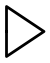

In [3]:
BGA824N6

## Create System

In [4]:
rx_001 = System(
    "GPS RX",
    "xcvr inc.",
    "001",
    [
        X4C20J1_20G,
        SKY55950,
        PAT0510S_C_1DB,
        BGA824N6,
        PAT0510S_C_1DB,
        BGA824N6,
        PAT0510S_C_1DB,
    ],
)

bw = 35.59*ureg.MHz
pwr = ureg.boltzmann_constant*bw*(37*ureg.celsius)
pwr=0*ureg.dBm
f=(1.575*ureg.GHz).to("Hz")
vspan=dict(xmin=1.557e9,xmax=1.610e9,alpha=0.3)

## View System

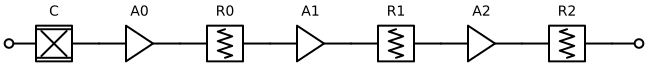

In [5]:
d=rx_001.block_diagram()
d

## Tabulated Ouput

In [6]:
rx_001.get_device_attr("gain")


Magnitude,[[1.5064043432961483 1.4787523158878972 1.3268752451952106 ... 67.39253969030395 67.52401996601903 67.65484033715056] [-54.73397438415919 -55.53009384954852 -60.46204141356334 ... 72.30194113260833 72.36737751825228 72.43264999152504] [-0.9994394893461198 -0.9970000000000001 -0.987999999999999 ... 54.73430470708638 54.86369778650535 54.99244896886851] ... [-0.9994394893461198 -0.9970000000000001 -0.987999999999999 ... 54.73430470708638 54.86369778650535 54.99244896886851] [-45.99743356399999 -48.19008337665841 -27.897746898120516 ... -48.1445568403 -49.0484208486 -49.5355737289] [-0.9994394893461198 -0.9970000000000001 -0.987999999999999 ... 54.73430470708638 54.86369778650535 54.99244896886851]]
Units,decibel


In [7]:
rx_001.get_dataframe(input_power=pwr.to("dBm"), frequency=f.magnitude,method="nearest")


,device,frequency,manufacturer,pn,gain,nf,p1db,psat,cascaded_gain,cascaded_nf,cascaded_p1db,cascaded_psat,cascaded_oip3,cascaded_iip3,vsup,isup,pdiss,cascaded_pdiss,signal_level
0,C,1.575e+09,TTM,X4C20J1-20G,-0.10,0.10,inf,inf,-0.10,0.10,inf,inf,inf,-32.540000,0.000000,0,0.000000,0.000000,-0.10
1,A0,1.575e+09,Skyworks,SKY55950,16.15,2.00,10.00,11.00,16.06,2.10,10.00,11.00,-5.000000,-32.640000,2.800000,2,5.600000,5.600000,11.00
2,R0,1.575e+09,Susumu,PAT0510S-C-1DB,-1.13,1.13,inf,inf,14.92,2.12,8.87,9.87,-6.130000,-16.490000,0.000000,0,0.000000,5.600000,9.87
3,A1,1.575e+09,Infineon,BGA824N6,17.16,0.80,10.00,11.00,32.09,2.13,9.89,11.00,9.830000,-17.620000,3.300000,5,16.500000,22.100000,11.00
4,R1,1.575e+09,Susumu,PAT0510S-C-1DB,-1.13,1.13,inf,inf,30.95,2.14,8.76,9.87,8.700000,-0.460000,0.000000,0,0.000000,22.100000,9.87
5,A2,1.575e+09,Infineon,BGA824N6,17.16,0.80,10.00,11.00,48.12,2.14,9.89,11.00,15.570000,-1.590000,3.300000,5,16.500000,38.600000,11.00
6,R2,1.575e+09,Susumu,PAT0510S-C-1DB,-1.13,1.13,inf,inf,46.98,2.14,8.76,9.87,14.440000,15.570000,0.000000,0,0.000000,38.600000,9.87


## Graphical Gain Representation

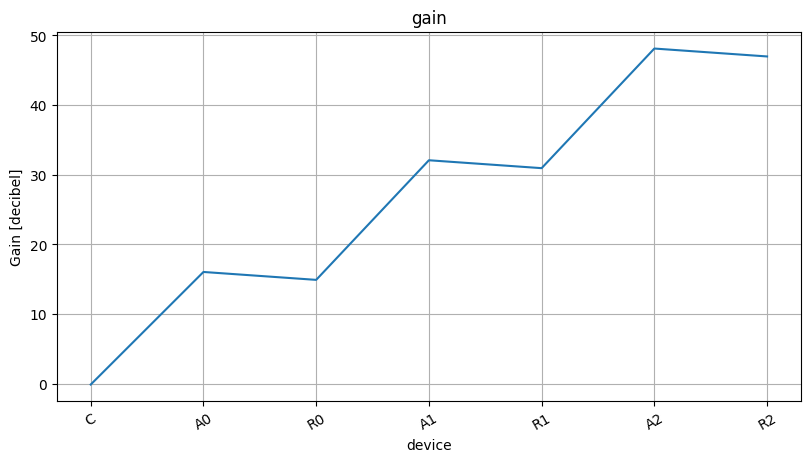

In [8]:
ax = plot_cascade(rx_001,frequency=1.575e9)
ax.grid()

## Signal Compression

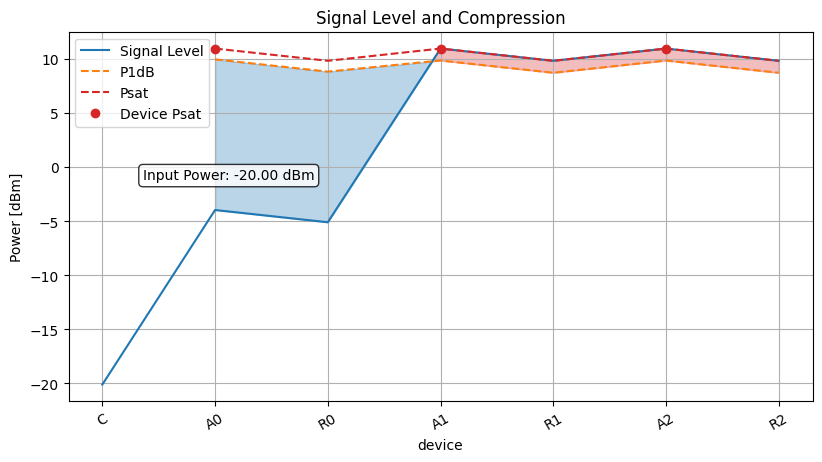

In [9]:
input_pwr = xr.DataArray([-20]*ureg.dBm, dims=("frequency",),coords=dict(frequency=[1.575e9]))
ax = plot_signal_compression(rx_001,input_pwr,frequency=1.575e9)
ax.grid()

Plot Cascaded Network Data with skrf

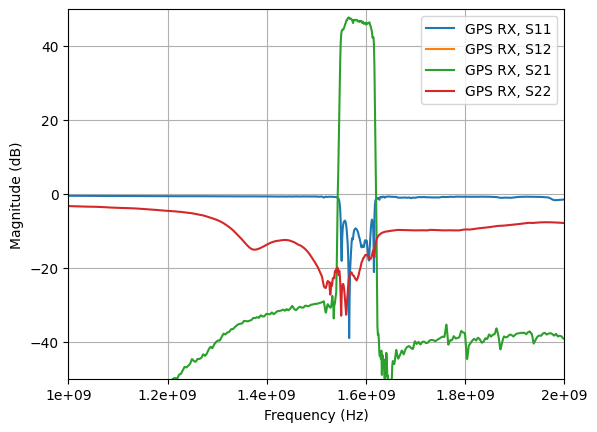

In [10]:
rx_001.network.plot_s_db()
ax=plt.gca()
ax.set_ylim(-50,50)
ax.set_xlim(1e9,2e9)
ax.grid()

## Sub-system Example

Use same components but split into two systems.

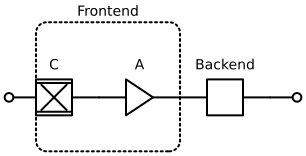

In [ ]:
frontend = System("Frontend", "xcvr", "FE-001", [X4C20J1_20G, SKY55950])
backend  = System("Backend",  "xcvr", "BE-001", [PAT0510S_C_1DB,
        BGA824N6,
        PAT0510S_C_1DB,
        BGA824N6,
        PAT0510S_C_1DB,])

# Compose into a top-level system
full_rx = System("Full RX", "xcvr", "RX-001", [frontend, backend])

# Expand the frontend to show its individual devices in the block diagram
frontend.expand = True
backend.expand = False
full_rx.block_diagram()

In [18]:
full_rx.get_dataframe(input_power=pwr.to("dBm"), frequency=f.magnitude,method="nearest")


,device,frequency,manufacturer,pn,gain,nf,p1db,psat,cascaded_gain,cascaded_nf,cascaded_p1db,cascaded_psat,cascaded_oip3,cascaded_iip3,vsup,isup,pdiss,cascaded_pdiss,signal_level
0,C,1.575e+09,TTM,X4C20J1-20G,-0.10,0.10,inf,inf,-0.10,0.10,inf,inf,inf,-32.630000,0.000000,0,0.000000,0.000000,-0.10
1,A,1.575e+09,Skyworks,SKY55950,16.15,2.00,10.00,11.00,16.06,2.10,10.00,11.00,-5.000000,-32.730000,2.800000,2,5.600000,5.600000,11.00
2,Backend,1.575e+09,xcvr,BE-001,31.02,1.97,8.76,9.87,47.07,2.14,8.76,9.87,14.450000,-16.570000,0.000000,0,33.000000,38.600000,9.87
